In [1]:
import os
import torch
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from optuna.integration import PyTorchLightningPruningCallback
import pandas as pd
import optuna
from torch.distributions import Uniform
from ml4gw.waveforms import SineGaussian
import numpy as np
import amplfi

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
os.environ['AMPLFI_OUTDIR'] = '/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/sg'
os.environ['AMPLFI_DATADIR'] = '/home/aframe/dev/o4_llpic/amplfi/hl/data'
config_path ='/home/jack.redepenning/amplfi_dir/amplfi/runs/sg/sg.yaml'

In [2]:
ckpt_path = "/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg_sky_loc/best.ckpt"
config_path = "/home/jack.redepenning/amplfi_dir/amplfi/runs/sg_sky_loc/sg.yaml"
param_path = "/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg/parameters.hdf5"

/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/cli.py:528: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line argument

2025-08-25 10:20:34,658 - root - INFO - Downloading data to /home/aframe/dev/o4_llpic/amplfi/hl/data


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: redep028 (redep028-university-of-minnesota). Use `wandb login --relogin` to force relogin


2025-08-25 10:20:41,351 - FlowDataset - INFO - Setting up data for stage TrainerFn.TESTING
2025-08-25 10:20:41,357 - FlowDataset - INFO - Using 83 files with a total duration of 9.444 days for testing
2025-08-25 10:20:41,363 - FlowDataset - INFO - Inferred sample rate of 2048.0 Hz
2025-08-25 10:20:41,366 - FlowDataset - INFO - Loaded 1 waveforms for testing
2025-08-25 10:20:41,368 - FlowDataset - INFO - Building torch Modules and transferring to device
2025-08-25 10:20:41,370 - FlowDataset - INFO - Using pre-fit standard scaler


Restoring states from the checkpoint path at /home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg_sky_loc/best.ckpt
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:362: The dirpath has changed from '/projects/bcse/jredepenning//amplfi-outdir/run5/sg_sky_loc/train_logs/amplfi/re0zo7ef/checkpoints' to '/home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/sg/train_logs/amplfi/ypdfxvo6/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loaded model weights from the checkpoint at /home/jack.redepenning/amplfi_dir/amplfi-outdir/runs/finished_model/sg_sky_loc/best.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

2025-08-25 10:21:29,765 - FlowModel - INFO - Removed 20/10000 total samples outside of prior range
2025-08-25 10:21:31,575 - FlowModel - INFO - Making PP plot


10:21 bilby INFO    : Key: KS-test p-value
10:21 bilby INFO    : phase: 0.7294589178356712
10:21 bilby INFO    : dec: 0.9144288577154309
10:21 bilby INFO    : psi: 0.6741482965931864
10:21 bilby INFO    : phi: 0.9068136272545089
10:21 bilby INFO    : Combined p-value: 0.9866874185229559


Crossmatching skymaps:   0%|          | 0/1 [00:00<?, ?it/s]

/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/ligo/skymap/postprocess/crossmatch.py:395: RuntimeWarning: invalid value encountered in subtract
  contour_dists = (hi - lo).tolist()
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/ligo/skymap/postprocess/crossmatch.py:414: RuntimeWarning: invalid value encountered in divide
  dP_dV = dP / dV
TEST Profiler Report

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|  Action                                                                                                                                                           	|  Mean duration (s)	|  Num calls      	|  Total time (s) 	|  Percentage %   	|
-------------------------------------------------------------------

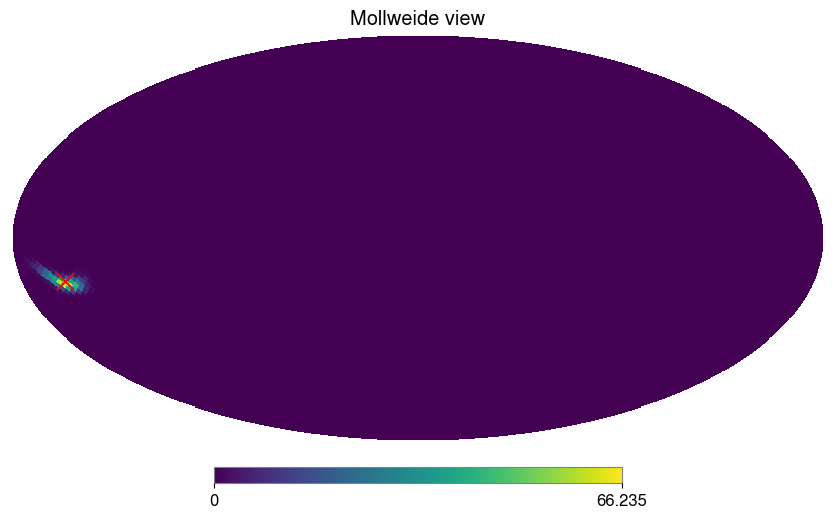

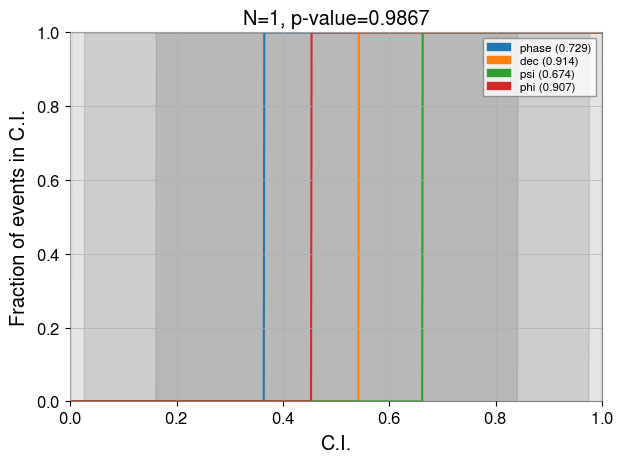

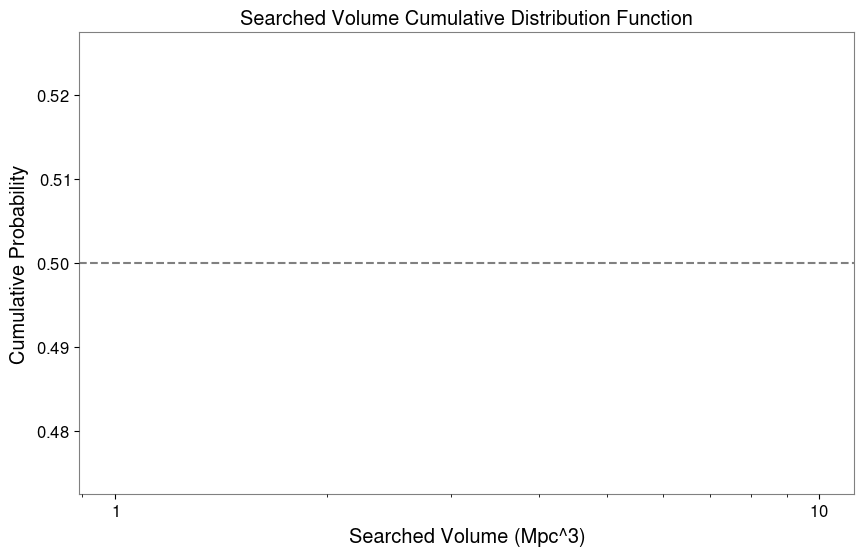

In [3]:
from amplfi.train.data.datasets.base import AmplfiDataset
from amplfi.train.models.base import AmplfiModel
from amplfi.train.cli.flow import AmplfiFlowCLI

cli = AmplfiFlowCLI(
        AmplfiModel,
        AmplfiDataset,
        subclass_mode_model=True,
        subclass_mode_data=True,
        save_config_kwargs={"overwrite": True},
        seed_everything_default=101588,
        args=[
        "test",             # Subcommand
        "--config", config_path,
        "--ckpt_path", ckpt_path,
        ]
)

In [4]:
from tqdm import tqdm
from torch.utils.data import DataLoader

def prepare_data(datamodule):
    datamodule.transforms_to_device()
    train_dataloader = datamodule.train_dataloader()
    val_dataloader = datamodule.val_dataloader()
    train_batch = []
    val_batch = []
    datamodule.trainer.training = True
    for batch in tqdm(train_dataloader):
        t_batch = datamodule.on_after_batch_transfer(batch, device)
        train_batch.append(t_batch)
    
    datamodule.trainer.training = False
    datamodule.trainer.validating = True
    for batch in tqdm(val_dataloader):
        v_batch = datamodule.on_after_batch_transfer(batch, device)
        val_batch.append(v_batch)

    train_dataloader = DataLoader(train_batch, batch_size=None)
    val_dataloader = DataLoader(val_batch, batch_size=None)

    return train_dataloader, val_dataloader

In [5]:
def objective(trial):
    batch_size = trial.suggest_int("batch_size", 128, 1024, log=True)
    learning_rate = trial.suggest_float("learning_rate", 7.14e-5, 7.14e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 4.2e3, 4.2e5, log=True)
    batches_per_epoch = trial.suggest_int("batches_per_epoch", 2, 5)
    model = cli.model
    model.eval();
    datamodule = cli.datamodule
    datamodule.transforms_to_device()
    datamodule.setup("fit")
    model.hparams["learning_rate"] = learning_rate
    model.hparams["weight_decay"] = weight_decay
    datamodule.hparams["batch_size"] = batch_size
    datamodule.hparams["batches_per_epoch"] = batches_per_epoch

    train_dataloader, val_dataloader = prepare_data(datamodule)

    pruning_callback = PyTorchLightningPruningCallback(trial, monitor='val_loss')

    trainer = cli.trainer
    trainer.callbacks = [pruning_callback]
    trainer.fit(model, train_dataloader, val_dataloader)
    print(trainer.callback_metrics['val_loss'].item())

    return trainer.callback_metrics['val_loss'].item()


In [7]:
trainer = cli.trainer

In [12]:
trainer

In [6]:
n_trials = 1
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=n_trials)

[I 2025-08-25 10:21:46,674] A new study created in memory with name: no-name-6efc75dc-6488-40a3-b112-b7ce8bc258b7


2025-08-25 10:21:46,680 - FlowDataset - INFO - Setting up data for stage fit
2025-08-25 10:21:47,151 - FlowDataset - INFO - Using 377 files with a total duration of 45.664 days for training
2025-08-25 10:21:47,152 - FlowDataset - INFO - Using 4 files with a total duration of 0.246 days for validation
2025-08-25 10:21:47,656 - FlowDataset - INFO - Inferred sample rate of 2048.0 Hz
2025-08-25 10:21:49,508 - FlowDataset - INFO - Loaded 1 waveforms for validation
2025-08-25 10:21:49,509 - FlowDataset - INFO - Building torch Modules and transferring to device
2025-08-25 10:21:49,511 - FlowDataset - INFO - Fitting standard scaler to parameters
2025-08-25 10:22:13,147 - FlowDataset - INFO - Using a Hdf5TimeSeriesDataset class for training


100%|██████████| 1/1 [00:00<00:00, 24.58it/s]

2025-08-25 10:24:08,721 - FlowDataset - INFO - Setting up data for stage TrainerFn.FITTING
2025-08-25 10:24:08,728 - FlowDataset - INFO - Using 377 files with a total duration of 45.664 days for training
2025-08-25 10:24:08,729 - FlowDataset - INFO - Using 4 files with a total duration of 0.246 days for validation
2025-08-25 10:24:08,737 - FlowDataset - INFO - Inferred sample rate of 2048.0 Hz


2025-08-25 10:24:09,411 - FlowDataset - INFO - Loaded 1 waveforms for validation
2025-08-25 10:24:09,413 - FlowDataset - INFO - Building torch Modules and transferring to device
2025-08-25 10:24:09,415 - FlowDataset - INFO - Fitting standard scaler to parameters


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loading `train_dataloader` to estimate number of stepping batches.


2025-08-25 10:24:09,604 - FlowModel - INFO - Saving Wandb Url


/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/home/jack.redepenning/amplfi_dir/amplfi/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
[W 2025-08-25 10:2

OutOfMemoryError: CUDA out of memory. Tried to allocate 446.00 MiB. GPU 0 has a total capacity of 15.77 GiB of which 364.25 MiB is free. Process 3960986 has 392.00 MiB memory in use. Including non-PyTorch memory, this process has 14.59 GiB memory in use. Process 4002796 has 442.00 MiB memory in use. Of the allocated memory 14.19 GiB is allocated by PyTorch, and 16.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
datamodule = cli.datamodule
model = cli.model
model.eval();

### Load in background data 

In [ ]:
waveforms_dataloader, background_dataloader = datamodule.test_dataloader().datasets
background_data = next(iter(background_dataloader))
background_data = background_data[0][0].repeat(num_waveforms, 1, 1)
print(background_data.shape)

torch.Size([1, 2, 38912])


In [ ]:
X = background_data
splits = [X.size(-1) - size, size]
background, X = torch.split(X, splits, dim=-1)

In [ ]:
print(background.shape)
print(X.shape)

torch.Size([1, 2, 24576])
torch.Size([1, 2, 14336])


### Inject sg waveforms into the background data and use amplfi to predict waveform parameters

In [ ]:
strain, asds, parameters, snrs = datamodule.inject(background_data, cross, plus, params)
batch = strain, asds, parameters
print(strain.shape)
print(asds.shape)
print(parameters.shape)
print(snrs.shape)
result = model.predict_step(batch, _)

torch.Size([1, 2, 10240])
torch.Size([1, 2, 4995])
torch.Size([1, 4])
torch.Size([1])
2025-08-04 08:20:38,626 - FlowModel - INFO - Removed 10/10000 total samples outside of prior range


In [ ]:
result
params

{'frequency': tensor([188.8623]),
 'quality': tensor([27.8869]),
 'hrss': tensor([1.1554e-21]),
 'phase': tensor([6.0732]),
 'eccentricity': tensor([0.0048]),
 'dec': tensor([-0.8388]),
 'psi': tensor([0.9673]),
 'phi': tensor([3.7458])}

### Corner Plot